In [1]:

import pandas as pd

data =pd.read_excel(r"C:\Users\bhanu\Downloads\test_data.xlsx")

data.columns = data.columns.str.strip().str.lower()
print(data.head())

  test_case status   module       date
0       TC1   Pass    Login 2024-01-01
1       TC2   Fail     Cart 2024-01-02
2       TC3   Pass    Login 2024-01-03
3       TC4   Fail  Payment 2024-01-04
4       TC5   Fail     Cart 2024-01-05


status
Pass    5
Fail    5
Name: count, dtype: int64


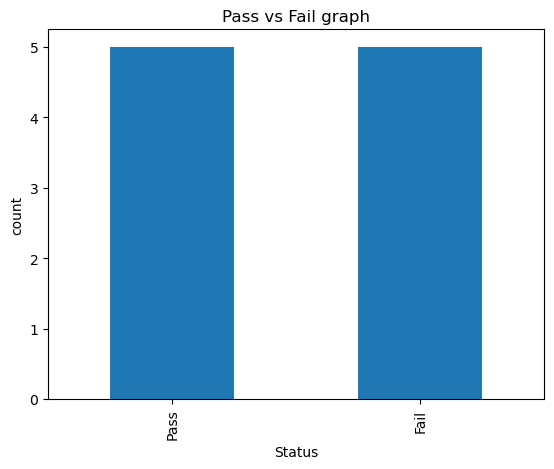

In [2]:
#pass vs fail graphs

import matplotlib.pyplot as plt

status_count= data["status"].value_counts()
print(status_count)

status_count.plot(kind="bar")
plt.title("Pass vs Fail graph")
plt.xlabel("Status")
plt.ylabel("count")
plt.show()

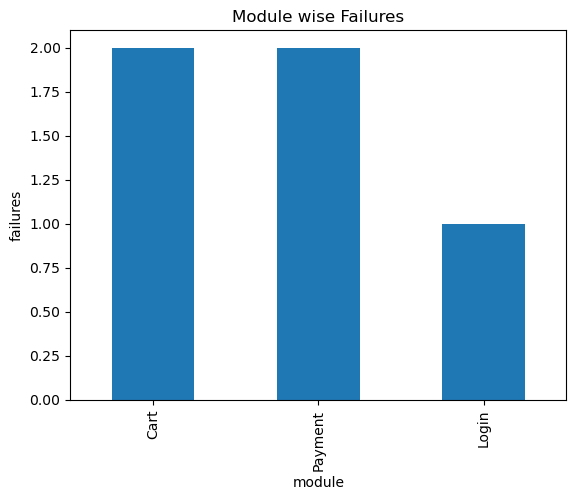

In [3]:
#Module-wise Failures

failures = data[data['status']=='Fail']

modules = failures["module"].value_counts()
modules

modules.plot(kind='bar')
plt.title("Module wise Failures")
plt.xlabel("module")
plt.ylabel("failures")
plt.show()

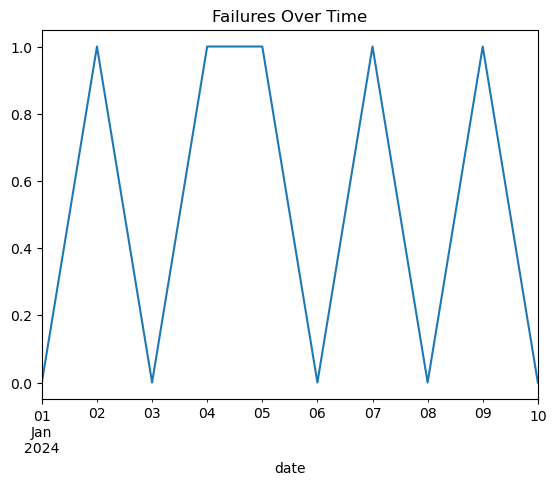

In [4]:
#failures over time

data['date'] = pd.to_datetime(data['date'])

trend = data.groupby('date')['status'].apply(lambda x:(x=='Fail').sum())

trend.plot(kind='line')
plt.title("Failures Over Time")
plt.show()


Type of Charts

Bar chart --> plot(kind="bar")
line chart --> plot(kind="line") -- trends over time
Pie Chart --> plot(kind="pie", autopct="%1.1f%%") -- used for small categories 
Histogram --> plot(kind="hist") -- shows distribution of values
Scatter plot --> data.plot(kind="scatter", x="id", y="execution_time") - shows relationship between 2 variables
Box plot --> data.boxplot(column="execution_time") -- shows outliers and spread of data
Stacked Bar chart --> pd.crosstab(data["module"], data["status"]).plot(kind="bar", stacked=True) -- useful for QA reports-module comparison


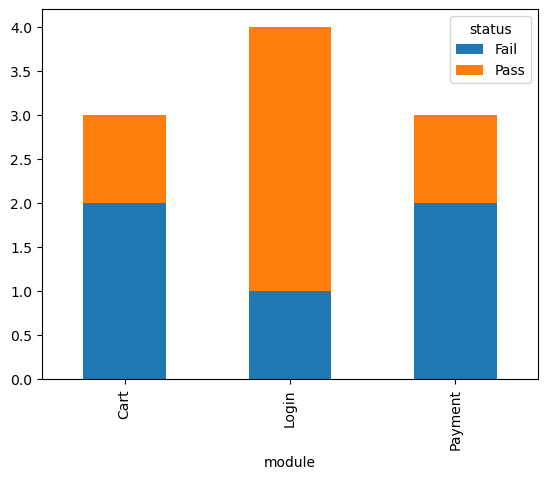

In [6]:
pd.crosstab(data["module"], data["status"]).plot(kind="bar", stacked=True)
plt.show()

value_counts() --> data['status'].value_counts() --> count frequency
groupby --> data.groupby('module')['status]' --> groupby for analysis
nunique() --> data['status'].nunique() --> count unique values
unique() --> data['status'].unique() --> get all unique values
count() --> data['status'].count() --> get total non null values
sum() --> (data['status']=='Fail').sum() --> count total
mean() --> data['status'].mean() --> get average
min()/max() --> data['status'].min()/data['status'].max() --> find extremes
describe() --> data.describe() --> displays mean,min,max,count
crosstab() --> pd.crosstab(data['module'],data['status']) --> to get QA reports
sort_values() --> data.sort_values(by='date') --> to sort data
isnull(),notnull --> data.isnull() --> to find missing values


In [8]:
#flaky test --> running a script many times to identify the inconsistent outcomes

import pandas as pd

data = {
    "test_case": ["TC1", "TC1", "TC1", "TC2", "TC2", "TC2"],
    "status": ["Pass", "Fail", "Pass", "Pass", "Pass", "Pass"]
}

print(data)
df = pd.DataFrame(data) #converting data type from dict to dataframe
print(df)

flaky_test=[]
grouped= df.groupby('test_case')['status']

for test,results in grouped:
    if 'Pass' in list(results) and 'Fail' in list(results):
        flaky_test.append(test)
print("Flaky Tests:", flaky_test)      
    


{'test_case': ['TC1', 'TC1', 'TC1', 'TC2', 'TC2', 'TC2'], 'status': ['Pass', 'Fail', 'Pass', 'Pass', 'Pass', 'Pass']}
  test_case status
0       TC1   Pass
1       TC1   Fail
2       TC1   Pass
3       TC2   Pass
4       TC2   Pass
5       TC2   Pass
Flaky Tests: ['TC1']


In [9]:
flaky = df.groupby("test_case")["status"].nunique()
print(flaky)
flaky_tests = flaky[flaky > 1]#>1 means both pass and fail
print('-------------')
print('flaky test is',flaky_tests)

test_case
TC1    2
TC2    1
Name: status, dtype: int64
-------------
flaky test is test_case
TC1    2
Name: status, dtype: int64


In [10]:
# with more columns

import pandas as pd

data =pd.read_excel(r"C:\Users\bhanu\Downloads\test_data.xlsx")

#print(data)
df = pd.DataFrame(data) #converting data type from dict to dataframe, not required in this case
#print(df)

#print failed modules with data and status
flaky = df.groupby(["module","status","date"]).size().reset_index(name='count')

fail_data = flaky[flaky["status"] == "Fail"]
print(fail_data)

    module status       date  count
0     Cart   Fail 2024-01-02      1
1     Cart   Fail 2024-01-05      1
3    Login   Fail 2024-01-07      1
7  Payment   Fail 2024-01-04      1
8  Payment   Fail 2024-01-09      1


In [11]:
#how many times each combination occurs

data1= df.groupby(["module", "status", "date"]).size().reset_index(name='numberof times')
print(data1)

    module status       date  numberof times
0     Cart   Fail 2024-01-02               1
1     Cart   Fail 2024-01-05               1
2     Cart   Pass 2024-01-08               1
3    Login   Fail 2024-01-07               1
4    Login   Pass 2024-01-01               1
5    Login   Pass 2024-01-03               1
6    Login   Pass 2024-01-10               1
7  Payment   Fail 2024-01-04               1
8  Payment   Fail 2024-01-09               1
9  Payment   Pass 2024-01-06               1


In [12]:
flaky1= df.groupby(["module","status","date"]).nunique()
print(flaky1)

                           test_case
module  status date                 
Cart    Fail   2024-01-02          1
               2024-01-05          1
        Pass   2024-01-08          1
Login   Fail   2024-01-07          1
        Pass   2024-01-01          1
               2024-01-03          1
               2024-01-10          1
Payment Fail   2024-01-04          1
               2024-01-09          1
        Pass   2024-01-06          1


In [13]:
flaky1= df.groupby(["test_case","status","date"]).nunique().reset_index()
print(flaky1)

  test_case status       date  module
0       TC1   Pass 2024-01-01       1
1      TC10   Pass 2024-01-10       1
2       TC2   Fail 2024-01-02       1
3       TC3   Pass 2024-01-03       1
4       TC4   Fail 2024-01-04       1
5       TC5   Fail 2024-01-05       1
6       TC6   Pass 2024-01-06       1
7       TC7   Fail 2024-01-07       1
8       TC8   Pass 2024-01-08       1
9       TC9   Fail 2024-01-09       1


In [14]:
#failure detection pattern

#identify most failed cases
failed_tests = df[df['status']=='Fail']
pattern1 = failed_tests['test_case'].value_counts()
print(pattern1)

test_case
TC2    1
TC4    1
TC5    1
TC7    1
TC9    1
Name: count, dtype: int64


In [15]:
pattern2 = pattern1[pattern1>1]
print(pattern2)

Series([], Name: count, dtype: int64)


In [16]:
#identify module wise failure pattern

pattern1 = failed_tests['module'].value_counts()
print(pattern1)

module
Cart       2
Payment    2
Login      1
Name: count, dtype: int64


In [17]:
#identify failures over time

df['data'] = pd.to_datetime(df['date'])

trend = df.groupby("date")['status'].apply(lambda x:(x=='Fail').sum())
print(trend)
                                           

date
2024-01-01    0
2024-01-02    1
2024-01-03    0
2024-01-04    1
2024-01-05    1
2024-01-06    0
2024-01-07    1
2024-01-08    0
2024-01-09    1
2024-01-10    0
Name: status, dtype: int64


In [18]:
pattern3 = df[df["status"] == "Fail"].groupby(["module", "date"]).size().reset_index(name="fail_count")

print(pattern3)

    module       date  fail_count
0     Cart 2024-01-02           1
1     Cart 2024-01-05           1
2    Login 2024-01-07           1
3  Payment 2024-01-04           1
4  Payment 2024-01-09           1


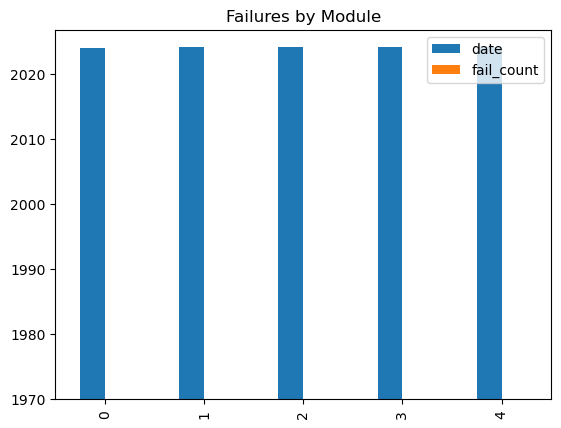

In [19]:
import matplotlib.pyplot as plt

pattern3.plot(kind="bar")
plt.title("Failures by Module")
plt.show()

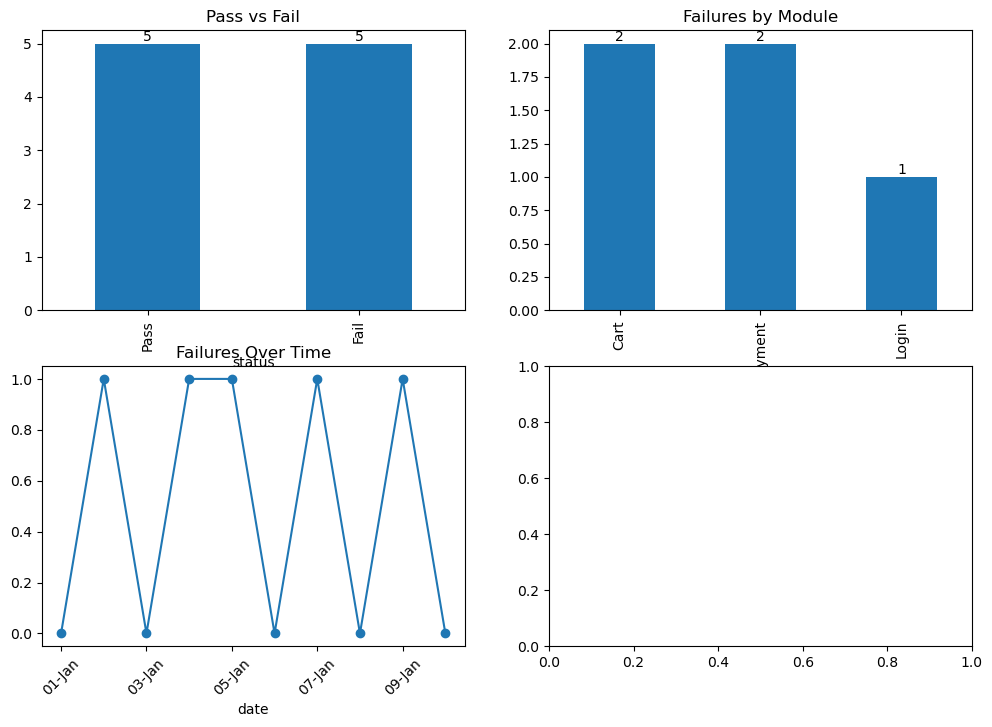

In [45]:
#Test Failure Dashboard
import matplotlib.dates as mdates

status_count = df["status"].value_counts()
module_fail = df[df["status"] == "Fail"]["module"].value_counts()
df["date"] = pd.to_datetime(df["date"])
trend = df.groupby("date")["status"].apply(lambda x: (x == "Fail").sum())
#trend = trend.head(5)
#top_tests = df[df["status"] == "Fail"]["test_case"].value_counts()
#top_tests = top_tests[top_tests > 1]

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Pass vs Fail
ax=axes[0,0]
status_count.plot(kind="bar",ax=ax)
ax.set_title("Pass vs Fail")
ax.bar_label(ax.containers[0])

# 2. Module Failures
ax1=axes[0,1]
module_fail.plot(kind="bar",ax=ax1)
ax1.set_title("Failures by Module")
ax1.bar_label(ax1.containers[0])

# 3. Trend
ax3=axes[1,0]
trend.index = pd.to_datetime(trend.index)
trend.index = trend.index.strftime("%d-%b")
trend.plot(kind="line",marker='o',ax=ax3)
ax3.set_title("Failures Over Time")
'''for i,v in enumerate(trend):
    ax3.text(i,v,str(v))'''

'''for x, y in zip(trend.index, trend.values):
    ax3.text(x, y, str(y))'''

#ax3.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
ax3.tick_params(axis='x',rotation=45)
    
# 4. Top Tests
'''plt.subplot(2,2,4)
top_tests.plot(kind="bar")
plt.title("Top Failing Tests")'''

#plt.tight_layout()
plt.show()

In [21]:
print(len(trend))

10


In [55]:
#Ranking critical test

#rank by failure count

failed_tests = df[df["status"] == "Fail"]
ranking = failed_tests["test_case"].value_counts()
print(ranking)
ranking.columns = ['test_case','fail_count']

test_case
TC2    1
TC4    1
TC5    1
TC7    1
TC9    1
Name: count, dtype: int64


In [49]:
#filter high priority cases

critical = ranking[ranking > 1]
print(critical)
#no high priority cases

Series([], Name: count, dtype: int64)


In [53]:
#check flakiness

flaky = df.groupby("test_case")["status"].nunique().reset_index(name="flaky_flag")
# flaky_flag = 2 → flaky
flaky

,test_case,flaky_flag
0,TC1,1
1,TC10,1
2,TC2,1
3,TC3,1
4,TC4,1
5,TC5,1
6,TC6,1
7,TC7,1
8,TC8,1
9,TC9,1


In [57]:
#merge both

final = pd.merge(ranking, flaky, on="test_case")
print(final)

  test_case  count  flaky_flag
0       TC2      1           1
1       TC4      1           1
2       TC5      1           1
3       TC7      1           1
4       TC9      1           1


In [63]:
#sorting
final = final.sort_values(by=["count", "flaky_flag"], ascending=False)

print(final)

  test_case  count  flaky_flag
0       TC2      1           1
1       TC4      1           1
2       TC5      1           1
3       TC7      1           1
4       TC9      1           1


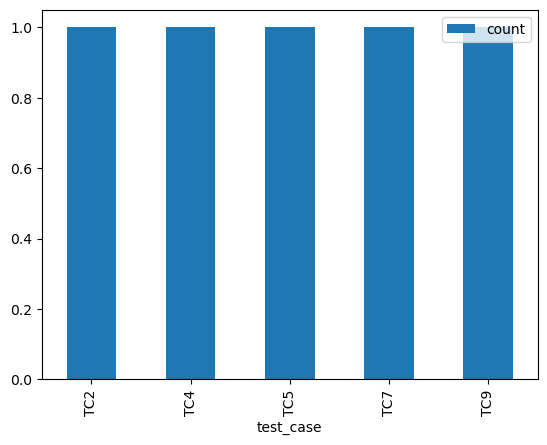

In [69]:
#visualization

final.plot(kind="bar", x="test_case", y="count")
plt.show()